In [56]:
from matplotlib import pyplot as plt
from dataclasses import dataclass
import json
from pathlib import Path
from scripts.common import (
    BenchMatrix,
    Tool,
    get_matrix_base_name,
    get_matrix_filename_mtx,
)
import yaml
import math
import numpy as np


In [57]:
@dataclass
class Results:
    fsharp_results: dict
    inpla_results: dict
    lagraph_results: dict
    networkx_results: dict
    vine_results: dict

In [58]:
def load_results(raw_results_path: Path) -> Results:
    try:
        fsharp_results_json = sorted(
            raw_results_path.glob("*_fsharp.json"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[0]
        with open(fsharp_results_json, "r", encoding="utf-8") as f:
            fsharp_results = json.load(f)
            print("Read", fsharp_results_json)
    except FileNotFoundError:
        print("QTreeFSharp results weren't found")
        fsharp_results = dict()

    try:
        inpla_results_json = sorted(
            raw_results_path.glob("*_inpla.json"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[0]
        with open(inpla_results_json, "r", encoding="utf-8") as f:
            inpla_results = json.load(f)
            print("Read", inpla_results_json)
    except FileNotFoundError:
        print("Inpla results weren't found")
        inpla_results = dict()

    try:
        lagraph_results_json = sorted(
            raw_results_path.glob("*_lagraph.json"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[0]
        with open(lagraph_results_json, "r", encoding="utf-8") as f:
            lagraph_results = json.load(f)
            print("Read", lagraph_results_json)
    except FileNotFoundError:
        print("LAGraph results weren't found")
        lagraph_results = dict()

    try:
        networkx_results_json = sorted(
            raw_results_path.glob("*_networkx.json"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[0]
        with open(networkx_results_json, "r", encoding="utf-8") as f:
            networkx_results = json.load(f)
            print("Read", networkx_results_json)
    except FileNotFoundError:
        print("QTreeFSharp results weren't found")
        networkx_results = dict()

    try:
        vine_results_json = sorted(
            raw_results_path.glob("*_vine.json"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[0]
        with open(vine_results_json, "r", encoding="utf-8") as f:
            vine_results = json.load(f)
            print("Read", vine_results_json)
    except FileNotFoundError:
        print("QTreeVine results weren't found")
        vine_results = dict()

    return Results(
        fsharp_results, inpla_results, lagraph_results, networkx_results, vine_results
    )

In [59]:
results = load_results(Path("results") / "raw")

Read results/raw/2026-04-28T19:45+03:00_fsharp.json
Read results/raw/2026-04-30T10_28+03_00_inpla.json
Read results/raw/2026-04-29T14:16+03:00_lagraph.json
Read results/raw/2026-04-29T14:00+03:00_networkx.json
Read results/raw/20260429_085711_vine.json


In [60]:
with open(Path("matrices.yaml"), "r", encoding="utf-8") as m_file:
    matrices: list[BenchMatrix] = yaml.safe_load(m_file)
enabled_matrices = filter(lambda matrix: matrix["enabled"], matrices)

In [61]:
thread_counts = [1] + list(range(2, 16 + 1, 2))

In [62]:
def get_inpla_time(result: str) -> float:
    if "Error".casefold() in result.casefold():
        return math.nan
    return float(result.splitlines()[-1].split(" ")[-2])


def get_vine_time(result: str) -> float:
    return float(result.split(" ")[-2])


def get_lagraph_time(result: str) -> float:
    return float(result.splitlines()[-1].split(" ")[-2])

# Для coAuthor. Построить для lagraph  и inpla ускорение (относительно одного потока)

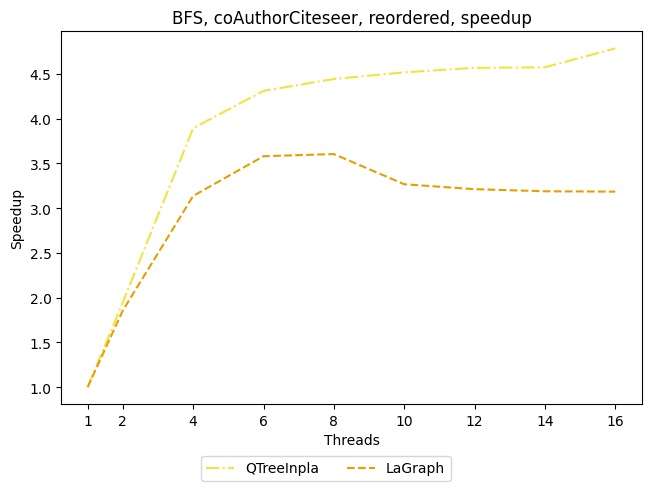

In [63]:
benchmark_result = results.inpla_results["bfs"]["coAuthorsCiteseer_reordered"]
coAuthor_inpla_times = []
for thread_count in thread_counts:
    times = list(map(get_inpla_time, benchmark_result[str(thread_count)]))
    coAuthor_inpla_times.append(np.nanmean(times))

benchmark_result = results.lagraph_results["bfs"]["coAuthorsCiteseer_reordered"]
coAuthor_lagraph_times = []
for thread_count in thread_counts:
    times = list(map(get_lagraph_time, benchmark_result[str(thread_count)]))
    coAuthor_lagraph_times.append(np.nanmean(times))

coAuthor_inpla_speedup = coAuthor_inpla_times[0] / coAuthor_inpla_times
coAuthor_lagraph_speedup = coAuthor_lagraph_times[0] / coAuthor_lagraph_times

fig, ax = plt.subplots(layout="constrained")
ax.set_title("BFS, coAuthorCiteseer, reordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

ax.plot(
    thread_counts,
    coAuthor_inpla_speedup,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    coAuthor_lagraph_speedup,
    color="#E69F00",
    linestyle="--",
    label="LaGraph",
)
fig.legend(loc="outside lower center", ncols=2)

# Для bone и usroads собрать всё (кроме lagraph и networkx) на один график. 


In [64]:
benchmark_result = results.inpla_results["bfs"]["usroads-48"]
usroads_inpla_times = []
usroads_inpla_error = []
for thread_count in thread_counts:
    times = list(map(get_inpla_time, benchmark_result[str(thread_count)]))
    usroads_inpla_times.append(np.nanmean(times))
    usroads_inpla_error.append(np.nanstd(times))

benchmark_result = results.inpla_results["bfs"]["usroads-48_reordered"]
usroads_reord_inpla_times = []
usroads_reord_inpla_error = []
for thread_count in thread_counts:
    times = list(map(get_inpla_time, benchmark_result[str(thread_count)]))
    usroads_reord_inpla_times.append(np.nanmean(times))
    usroads_reord_inpla_error.append(np.nanstd(times))

benchmark_result = list(
    filter(
        lambda res: "usroads-48.mtx".casefold() in res["FullName"].casefold(),
        results.fsharp_results["bfs"]["Benchmarks"],
    )
)[0]
usroads_fsharp_times = [benchmark_result["Statistics"]["Mean"] / 1e9] * len(
    thread_counts
)
usroads_fsharp_error = [
    benchmark_result["Statistics"]["StandardDeviation"] / 1e9
] * len(thread_counts)

benchmark_result = list(
    filter(
        lambda res: "usroads-48_reordered.mtx".casefold() in res["FullName"].casefold(),
        results.fsharp_results["bfs"]["Benchmarks"],
    )
)[0]
usroads_reord_fsharp_times = [benchmark_result["Statistics"]["Mean"] / 1e9] * len(
    thread_counts
)
usroads_reord_fsharp_error = [
    benchmark_result["Statistics"]["StandardDeviation"] / 1e9
] * len(thread_counts)


In [65]:
benchmark_result = results.inpla_results["bfs"]["boneS01"]
bone_inpla_times = []
bone_inpla_error = []
for thread_count in thread_counts:
    times = list(map(get_inpla_time, benchmark_result[str(thread_count)]))
    bone_inpla_times.append(np.nanmean(times))
    bone_inpla_error.append(np.nanstd(times))

benchmark_result = results.inpla_results["bfs"]["boneS01_reordered"]
bone_reord_inpla_times = []
bone_reord_inpla_error = []
for thread_count in thread_counts:
    times = list(map(get_inpla_time, benchmark_result[str(thread_count)]))
    bone_reord_inpla_times.append(np.nanmean(times))
    bone_reord_inpla_error.append(np.nanstd(times))

benchmark_result = list(
    filter(
        lambda res: "boneS01.mtx".casefold() in res["FullName"].casefold(),
        results.fsharp_results["bfs"]["Benchmarks"],
    )
)[0]
bone_fsharp_times = np.array(
    [benchmark_result["Statistics"]["Mean"] / 1e9] * len(thread_counts)
)
bone_fsharp_error = [benchmark_result["Statistics"]["StandardDeviation"] / 1e9] * len(
    thread_counts
)

benchmark_result = list(
    filter(
        lambda res: "boneS01_reordered.mtx".casefold() in res["FullName"].casefold(),
        results.fsharp_results["bfs"]["Benchmarks"],
    )
)[0]
bone_reord_fsharp_times = np.array(
    [benchmark_result["Statistics"]["Mean"] / 1e9] * len(thread_counts)
)
bone_reord_fsharp_error = [
    benchmark_result["Statistics"]["StandardDeviation"] / 1e9
] * len(thread_counts)


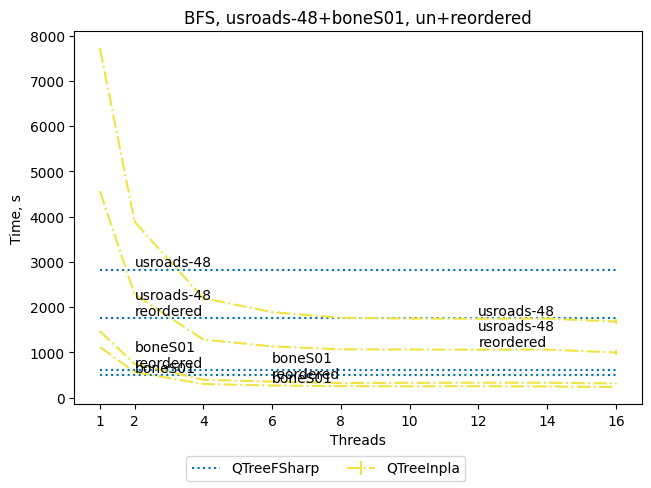

In [66]:

fig, ax = plt.subplots(layout="constrained")
ax.set_title("BFS, usroads-48+boneS01, un+reordered")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Time, s")

# usroads
ax.errorbar(
    thread_counts,
    usroads_inpla_times,
    yerr=usroads_inpla_error,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.text(
    thread_counts[-3],
    usroads_inpla_times[-3] + usroads_inpla_error[-3] + 5,
    "usroads-48",
    va="bottom",
)
ax.errorbar(
    thread_counts,
    usroads_reord_inpla_times,
    yerr=usroads_reord_inpla_error,
    color="#F0E442",
    linestyle="-.",
)
ax.text(
    thread_counts[-3],
    usroads_reord_inpla_times[-3] + usroads_reord_inpla_error[-3] + 5,
    "usroads-48\nreordered",
    va="bottom",
)
ax.plot(
    thread_counts,
    usroads_fsharp_times,
    color="#0072B2",
    linestyle=":",
    label="QTreeFSharp",
)
ax.text(
    thread_counts[1],
    usroads_fsharp_times[1] + usroads_fsharp_error[1] + 5,
    "usroads-48",
    va="bottom",
)
ax.plot(
    thread_counts,
    usroads_reord_fsharp_times,
    color="#0072B2",
    linestyle=":",
)
ax.text(
    thread_counts[1],
    usroads_reord_fsharp_times[1] + usroads_reord_fsharp_error[1] + 5,
    "usroads-48\nreordered",
    va="bottom",
)
# bone
ax.errorbar(
    thread_counts,
    bone_inpla_times,
    yerr=bone_inpla_error,
    color="#F0E442",
    linestyle="-.",
)
ax.text(
    thread_counts[-6],
    bone_inpla_times[-6] + bone_inpla_error[-6] + 5,
    "boneS01",
    va="bottom",
)
ax.errorbar(
    thread_counts,
    bone_reord_inpla_times,
    yerr=bone_reord_inpla_error,
    color="#F0E442",
    linestyle="-.",
)
ax.text(
    thread_counts[-6],
    bone_reord_inpla_times[-6] + bone_reord_inpla_error[-6] + 5,
    "boneS01\nreordered",
    va="bottom",
)
ax.plot(
    thread_counts,
    bone_fsharp_times,
    color="#0072B2",
    linestyle=":",
)
ax.text(
    thread_counts[1],
    bone_fsharp_times[1] + bone_fsharp_error[1] + 5,
    "boneS01",
    va="bottom",
)
ax.plot(
    thread_counts,
    bone_reord_fsharp_times,
    color="#0072B2",
    linestyle=":",
)
ax.text(
    thread_counts[1],
    bone_reord_fsharp_times[1] + bone_reord_fsharp_error[1] + 5,
    "boneS01\nreordered",
    va="bottom",
)
fig.legend(loc="outside lower center", ncols=2)


## Попробовать для этих ребят тоже ускорение построить. 

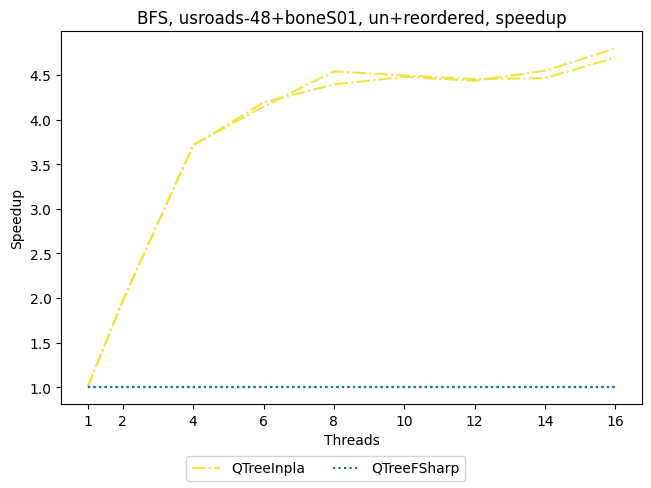

In [69]:
bone_inpla_speedup = bone_inpla_times[0] / bone_inpla_times
bone_fsharp_speedup = bone_fsharp_times[0] / bone_fsharp_times
bone_reord_inpla_speedup = bone_reord_inpla_times[0] / bone_reord_inpla_times
bone_reord_fsharp_speedup = bone_reord_fsharp_times[0] / bone_reord_fsharp_times


fig, ax = plt.subplots(layout="constrained")
ax.set_title("BFS, usroads-48+boneS01, un+reordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

ax.plot(
    thread_counts,
    bone_inpla_speedup,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    bone_fsharp_speedup,
        color="#0072B2",
        linestyle=":",
        label="QTreeFSharp",
)
ax.plot(
    thread_counts,
    bone_reord_inpla_speedup,
    color="#F0E442",
    linestyle="-.",
)
ax.plot(
    thread_counts,
    bone_reord_fsharp_speedup,
        color="#0072B2",
        linestyle=":",
)
fig.legend(loc="outside lower center", ncols=2)

# Для trefethen для всех попробовать нарисовать отношение времени bfs к sssp. Идея: оценить "расходы на арифметику" при одинаковой структуре вычислений.